# E5

### Misión 1

Compararemos dos representaciones de las obras: los pixeles de las imágenes y las características visuales entregadas. Luego aplicaremos PCA y t-SNE para estudiar cómo cambia la estructura de la colección.

#### Carga y representación de los datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances

In [2]:
metadata = pd.read_csv("E5_data/metadata.csv")
features = pd.read_csv("E5_data/features.csv")

In [3]:
filas = []

for filename in metadata["filename"]:
    image = Image.open("E5_data/images/" + filename)
    image = image.convert("RGB")
    image = image.resize((32, 32))
    pixels = np.asarray(image)
    pixels = pixels.reshape(-1)
    filas.append(pixels)

X_pixels = pd.DataFrame(filas) / 255.0

In [4]:

feature_cols = [c for c in features.columns if c.startswith("feature_")]
X_features = features[feature_cols]

print(f"pixeles: {X_pixels.shape}")
print(f"features: {X_features.shape}")

pixeles: (281, 3072)
features: (281, 1280)


Cada obra queda representada por 3072 pixeles (32 x 32 x 3) o por 1280 features. 

La representación de features es menos dimensional, pero esto no implica por si solo que produzca relaciones de similitud mas utiles.

#### Similitud entre obras

In [5]:
dist_pixels = pairwise_distances(X_pixels, metric="euclidean") # distancia entre puntos de pixeles
dist_features = pairwise_distances(X_features, metric="euclidean")

i = 0

vecinos_pixels = np.argsort(dist_pixels[i])[1:6] # te entrega el indice de los 5 vecinos más cercanos
vecinos_features = np.argsort(dist_features[i])[1:6]

print(f"Obra: {metadata.iloc[i]['title']}\n")

print("vecinos usando pixeles:")
display(metadata.iloc[vecinos_pixels][["title", "classification_title"]])
print()
print("vecinos usando features:")
display(metadata.iloc[vecinos_features][["title", "classification_title"]])

Obra: The Last Drop

vecinos usando pixeles:


,title,classification_title
239,Geese in a Farmyard,crayon
45,"The cannon 'Mons Meg' at Edinburgh Castle, and...",salted paper print
11,Two-Handled Covered Cup,drinking vessel
235,"The First Ten Minutes, plate two from The Leic...",aquatint
145,Les Propos de Thomas Vireloque: Misere et cord...,lithograph



vecinos usando features:


,title,classification_title
207,The Little Errand Girl,lithograph
235,"The First Ten Minutes, plate two from The Leic...",aquatint
239,Geese in a Farmyard,crayon
42,"Winter, from The Seasons",weaving - tapestry
275,The Triumph of Bacchus,print


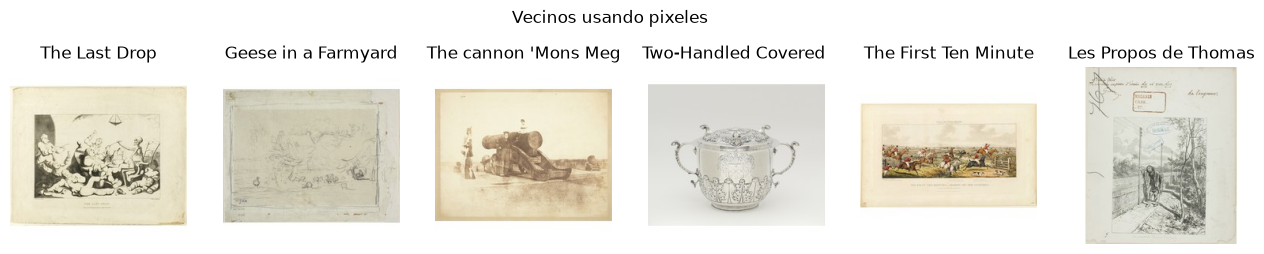

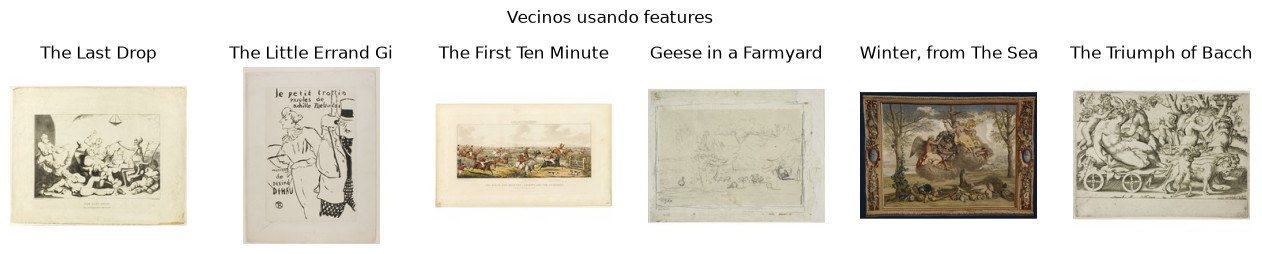

In [6]:
def mostrar_vecinos(i, vecinos, titulo):
    indices = [i] + list(vecinos)
    fig, axes = plt.subplots(1, 6, figsize=(16, 3))

    for ax, idx in zip(axes, indices):
        obra = metadata.iloc[idx]
        image = Image.open("E5_data/images/" + obra["filename"])
        ax.imshow(image)
        ax.set_title(str(obra["title"])[:20])
        ax.axis("off")

    fig.suptitle(titulo)
    plt.show()

mostrar_vecinos(i, vecinos_pixels, "Vecinos usando pixeles")
mostrar_vecinos(i, vecinos_features, "Vecinos usando features")

Fijémonos en que el color, la luminosidad y la distribución espacial de la imagen afectan mucho en los vecinos con pixeles. Pero las features son más robustas a estos "cambios", y por lo tanto producen vecinos más similares en cuanto a contenido y la composición misma.

#### Reducción de dimensionalidad con PCA

In [7]:
for n in [2, 10, 25, 50, 100]:
    pca_pixels = PCA(n_components=n)
    pca_features = PCA(n_components=n)

    pca_pixels.fit(X_pixels)
    pca_features.fit(X_features)

    print(
        f"{n} componentes - "
        f"pixeles: {pca_pixels.explained_variance_ratio_.sum():.2%} - "
        f"features: {pca_features.explained_variance_ratio_.sum():.2%}"
    )

2 componentes - pixeles: 58.30% - features: 11.64%
10 componentes - pixeles: 80.70% - features: 31.02%
25 componentes - pixeles: 89.51% - features: 47.82%
50 componentes - pixeles: 94.27% - features: 63.50%
100 componentes - pixeles: 97.61% - features: 80.94%


In [8]:
pca_pixels_90 = PCA(n_components=0.90)
X_pixels_pca = pca_pixels_90.fit_transform(X_pixels)

pca_features_90 = PCA(n_components=0.90)
X_features_pca = pca_features_90.fit_transform(X_features)

print(f"pixeles: {X_pixels.shape[1]} -> {X_pixels_pca.shape[1]}")
print(f"features: {X_features.shape[1]} -> {X_features_pca.shape[1]}")

pixeles: 3072 -> 27
features: 1280 -> 148


La comparación anterior permite observar cuántos componentes necesita cada representación para conservar el 90% de su varianza. Esto muestra qué tan concentrada se encuentra la información capturada por PCA en cada espacio.

Varianza PCA 2D - pixeles: 58.30%
Varianza PCA 2D - features: 11.64%


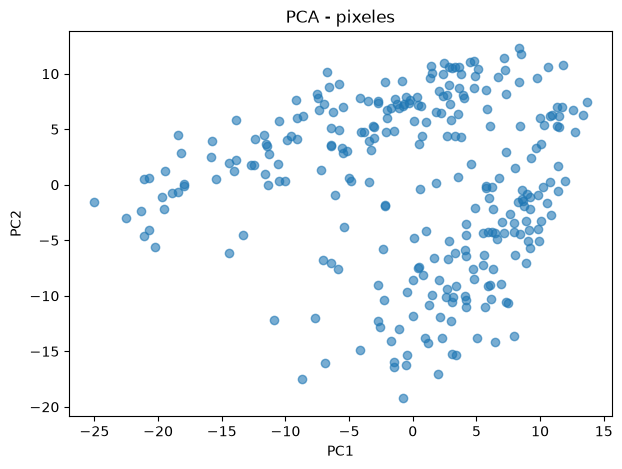

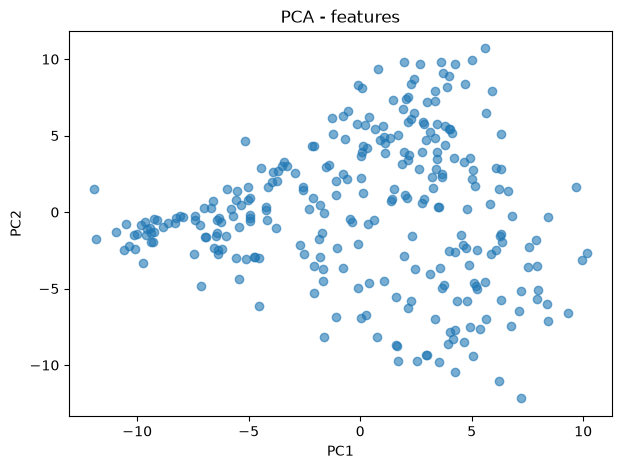

In [9]:
pca_pixels = PCA(n_components=2)
pixels_2d = pca_pixels.fit_transform(X_pixels)

pca_features = PCA(n_components=2)
features_2d = pca_features.fit_transform(X_features)

print(f"Varianza PCA 2D - pixeles: {pca_pixels.explained_variance_ratio_.sum():.2%}")
print(f"Varianza PCA 2D - features: {pca_features.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(7, 5))
plt.scatter(pixels_2d[:, 0], pixels_2d[:, 1], alpha=0.6)
plt.title("PCA - pixeles")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(features_2d[:, 0], features_2d[:, 1], alpha=0.6)
plt.title("PCA - features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

La representación de pixeles concentra una mayor proporción de su varianza en pocas componentes. 

Con 25 componentes ya conserva 89,51% de la varianza y necesita solo 27 para alcanzar 90%, mientras que las features requieren 148 componentes. 

PCA logra una reducción mucho mayor sobre los pixeles, aunque esto no indica que sea necesariamente la representación más útil para estudiar esto

#### Reducción de dimensionalidad con t-SNE

t-SNE permite estudiar relaciones locales en dos dimensiones. Sus resultados pueden cambiar al modificar los hiperparámetros, por lo que compararemos distintas perplexity (controla el equilibrio entre la estructura local y global de los datos al reducir su dimensionalidad)

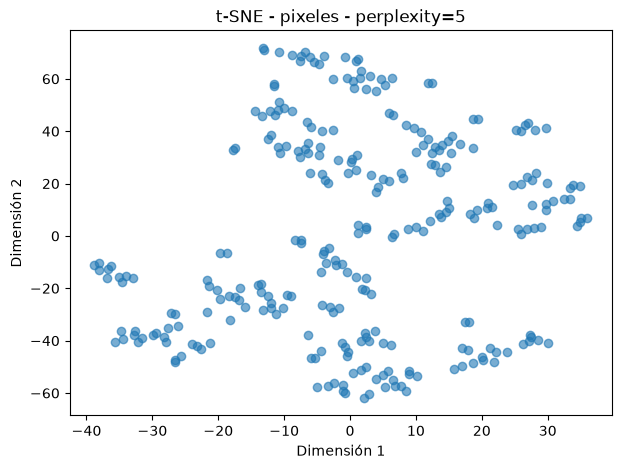

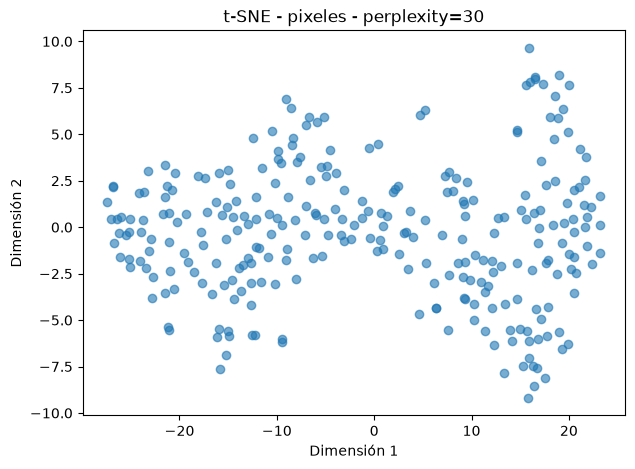

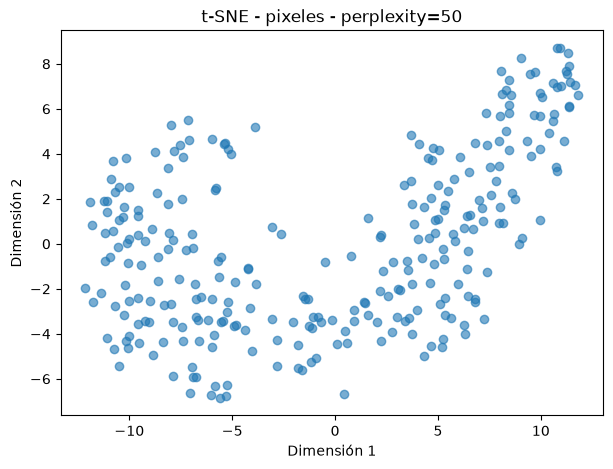

In [10]:
perplexities = [5, 30, 50]

for perplexity in perplexities:
    tsne_pixels = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=0
    )
    pixels_tsne = tsne_pixels.fit_transform(X_pixels)

    plt.figure(figsize=(7, 5))
    plt.scatter(pixels_tsne[:, 0], pixels_tsne[:, 1], alpha=0.6)
    plt.title(f"t-SNE - pixeles - perplexity={perplexity}")
    plt.xlabel("Dimensión 1")
    plt.ylabel("Dimensión 2")
    plt.show()

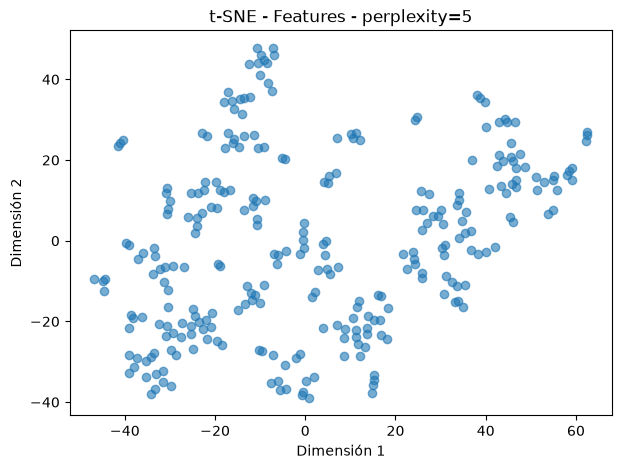

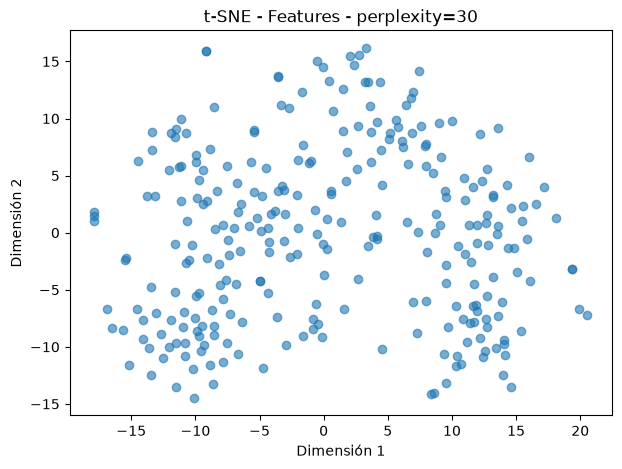

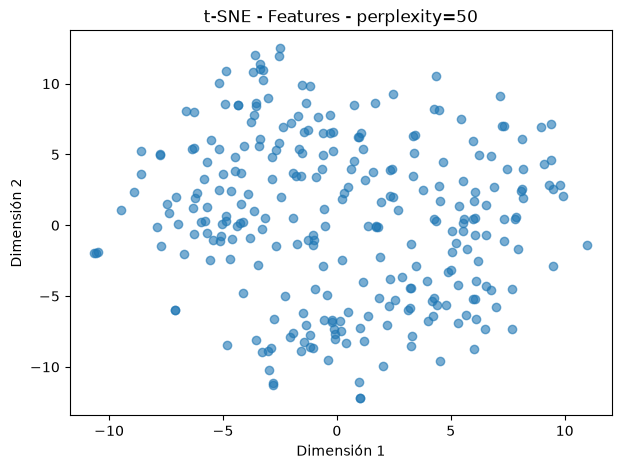

In [11]:
for perplexity in perplexities:
    tsne_features = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=0
    )
    features_tsne = tsne_features.fit_transform(X_features)

    plt.figure(figsize=(7, 5))
    plt.scatter(features_tsne[:, 0], features_tsne[:, 1], alpha=0.6)
    plt.title(f"t-SNE - Features - perplexity={perplexity}")
    plt.xlabel("Dimensión 1")
    plt.ylabel("Dimensión 2")
    plt.show()

Con perplexity=5, ambas representaciones presentan una estructura muy fragmentada en grupos pequeños. 

Al aumentar la perplexity a 30 y 50 aparecen estructuras más continuas, y para el ejercicio decimos que la configuración adecuada para la exploración es la que tiene perplexity=30, ya que mantiene relaciones locales visibles sin producir la fragmentación observada con valores menores, y tampoco se ve tan homogénea como con 50

#### Apoyo de los metadatos para interpretar la estructura

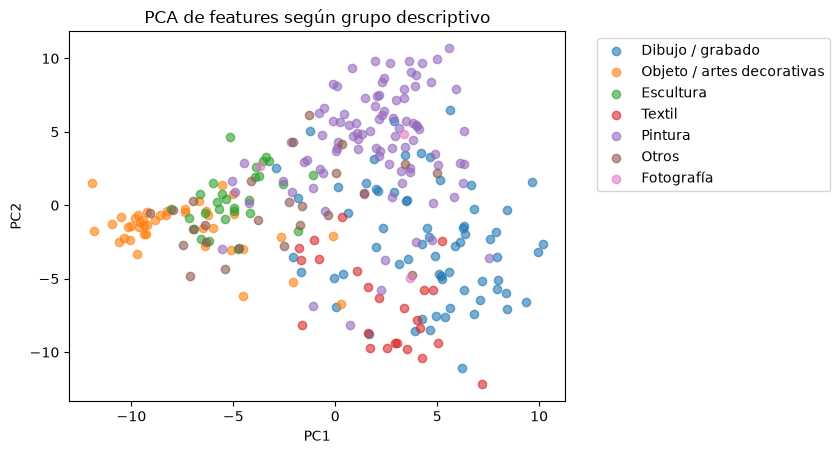

In [12]:
for grupo in metadata["selection_group"].dropna().unique():
    mask = metadata["selection_group"] == grupo
    plt.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=grupo,
        alpha=0.6
    )

plt.title("PCA de features según grupo descriptivo")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

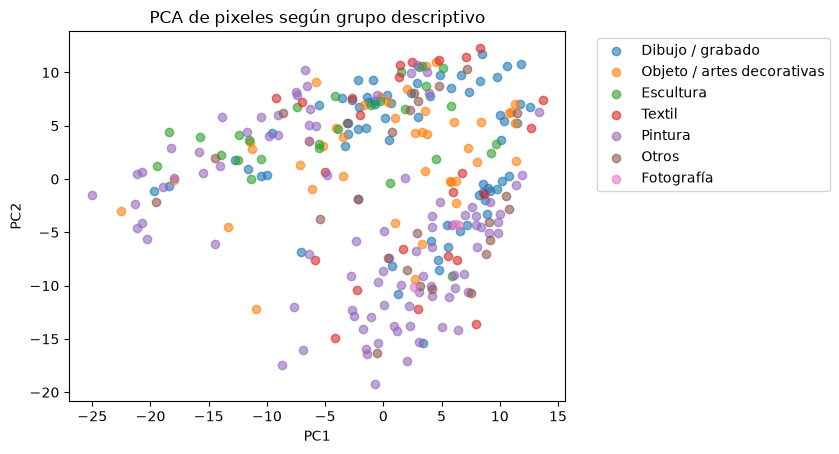

In [13]:
for grupo in metadata["selection_group"].dropna().unique():
    mask = metadata["selection_group"] == grupo
    plt.scatter(
        pixels_2d[mask, 0],
        pixels_2d[mask, 1],
        label=grupo,
        alpha=0.6
    )

plt.title("PCA de pixeles según grupo descriptivo")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [14]:
tsne_pixels = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=0
)
pixels_tsne = tsne_pixels.fit_transform(X_pixels)

tsne_features = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=0
)
features_tsne = tsne_features.fit_transform(X_features)

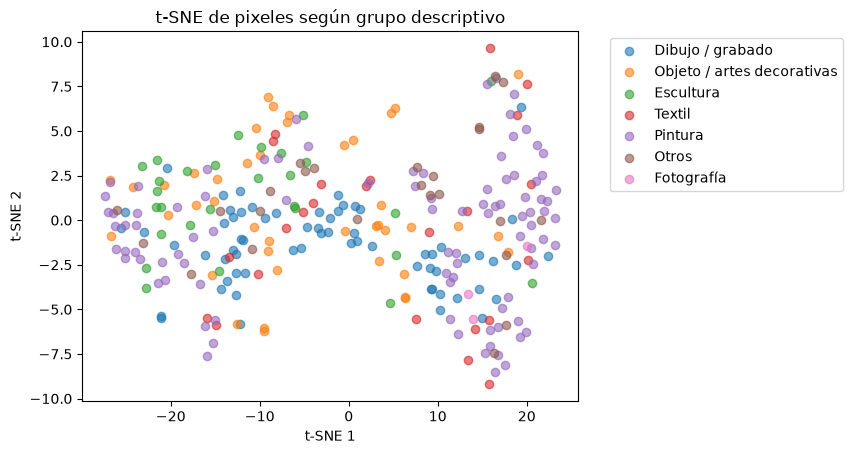

In [15]:
for grupo in metadata["selection_group"].dropna().unique():
    mask = metadata["selection_group"] == grupo
    plt.scatter(
        pixels_tsne[mask, 0],
        pixels_tsne[mask, 1],
        label=grupo,
        alpha=0.6
    )

plt.title("t-SNE de pixeles según grupo descriptivo")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

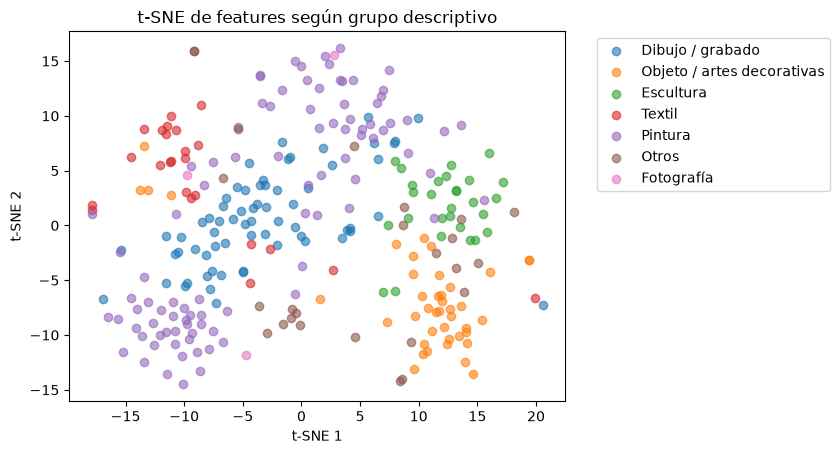

In [16]:
for grupo in metadata["selection_group"].dropna().unique():
    mask = metadata["selection_group"] == grupo
    plt.scatter(
        features_tsne[mask, 0],
        features_tsne[mask, 1],
        label=grupo,
        alpha=0.6
    )

plt.title("t-SNE de features según grupo descriptivo")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

### Conclusión

Las dos representaciones generan estructuras distintas. PCA permite reducirlos de 3072 a solo 27 componentes conservando el 90% de la varianza, mientras que las features requieren 148 componentes.

Sin embargo, como vimos, al analizar los vecinos de algunas obras, la representación mediante pixeles parece estar fuertemente influida por características como el color, la luminosidad y la distribución espacial de la imagen. 

Las features, en cambio, producen relaciones visuales más coherentes con el contenido y la composición de las obras.

Entonces, se ve que las features visuales son la representación más adecuada para estudiar la estructura de la colección. Para reducción de dimensionalidad, PCA resulta útil cuando interesa conservar una proporción explícita de la varianza, mientras que t-SNE con perplexity=30 ofrece una visualización útil de las relaciones locales entre las obras.

### Misión 2

In [17]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [18]:
representaciones = {
    "Pixeles": X_pixels,
    "Features": X_features,
    "pixeles PCA": X_pixels_pca,
    "Features PCA": X_features_pca
}

Partimos con probar distintos K con K-means

In [19]:
resultados = []

for nombre, X in representaciones.items():
    for k in range(2, 11):

        kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=0)

        labels = kmeans.fit_predict(X)

        resultados.append({
            "representacion": nombre,
            "k": k,
            "silhouette": silhouette_score(X, labels),
            "inercia": kmeans.inertia_
        })

resultados = pd.DataFrame(resultados)
resultados

,representacion,k,silhouette,inercia
0,Pixeles,2,0.219025,47274.119671
1,Pixeles,3,0.228566,36719.323774
2,Pixeles,4,0.198472,32300.457298
3,Pixeles,5,0.171464,29854.461587
4,Pixeles,6,0.147665,28242.347672
5,Pixeles,7,0.151562,27000.984767
6,Pixeles,8,0.140649,25839.468261
7,Pixeles,9,0.131857,24796.449412
8,Pixeles,10,0.124240,24148.943790
9,Features,2,0.047175,112041.514497


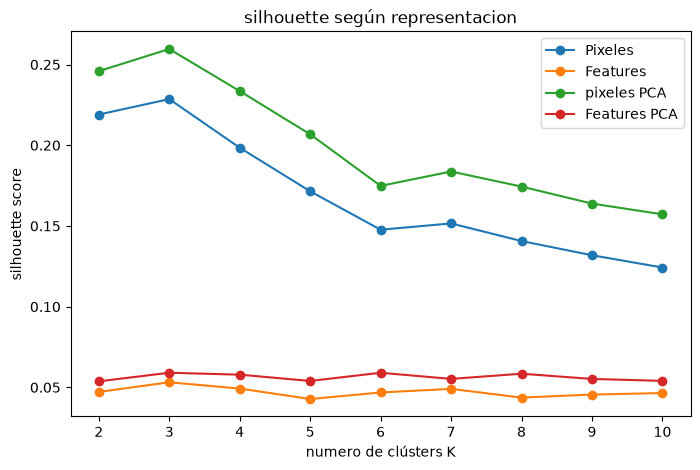

In [20]:
plt.figure(figsize=(8, 5))

for nombre in resultados["representacion"].unique():
    datos = resultados[resultados["representacion"] == nombre]

    plt.plot(
        datos["k"],
        datos["silhouette"],
        marker="o",
        label=nombre
    )

plt.xlabel("numero de clústers K")
plt.ylabel("silhouette score")
plt.title("silhouette según representacion")
plt.legend()
plt.show()

De forma automática, 

In [21]:
mejores = (resultados.loc[resultados.groupby("representacion")["silhouette"].idxmax()].sort_values("silhouette", ascending=False))

mejores

,representacion,k,silhouette,inercia
19,pixeles PCA,3,0.259619,30658.556138
1,Pixeles,3,0.228566,36719.323774
28,Features PCA,3,0.059061,95681.229337
10,Features,3,0.053144,107370.086865


In [22]:
resultados_agg = []

for nombre, X in representaciones.items():
    for k in range(2, 11):

        agg = AgglomerativeClustering(n_clusters=k)
        labels = agg.fit_predict(X)

        resultados_agg.append({
            "representacion": nombre,
            "k": k,
            "silhouette": silhouette_score(X, labels)
        })

resultados_agg = pd.DataFrame(resultados_agg)

In [23]:
mejores_agg = (resultados_agg.loc[resultados_agg.groupby("representacion")["silhouette"].idxmax()].sort_values("silhouette", ascending=False))

mejores_agg

,representacion,k,silhouette
19,pixeles PCA,3,0.256158
1,Pixeles,3,0.227066
28,Features PCA,3,0.053065
10,Features,3,0.049851


In [24]:
modelo_final = KMeans(n_clusters=3, n_init=10, random_state=0)

metadata["cluster"] = modelo_final.fit_predict(X_pixels_pca)

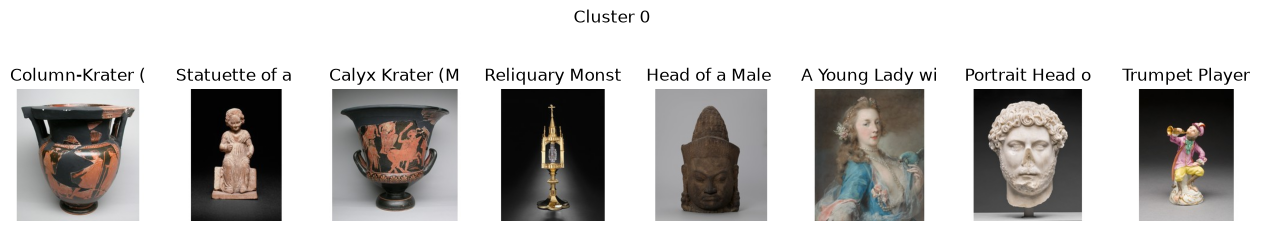

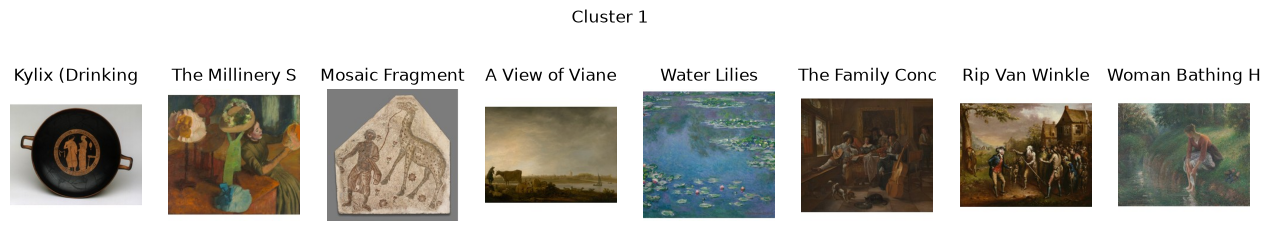

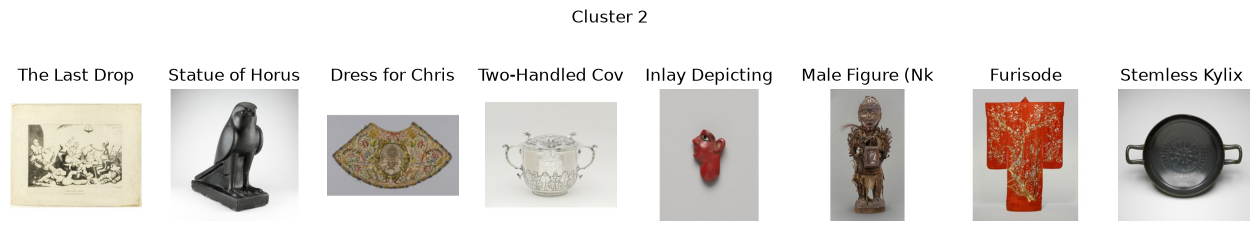

In [25]:
def mostrar_cluster(cluster, n=8):
    obras = metadata[metadata["cluster"] == cluster].head(n)

    fig, axes = plt.subplots(1, len(obras), figsize=(16, 3))

    for ax, (_, obra) in zip(axes, obras.iterrows()):
        image = Image.open("E5_data/images/" + obra["filename"])

        ax.imshow(image)
        ax.set_title(str(obra["title"])[:15])
        ax.axis("off")

    plt.suptitle(f"Cluster {cluster}")
    plt.show()

for cluster in sorted(metadata["cluster"].unique()):
    mostrar_cluster(cluster)

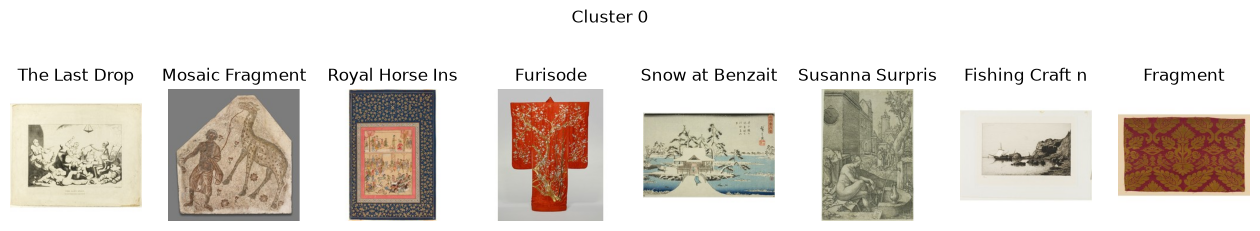

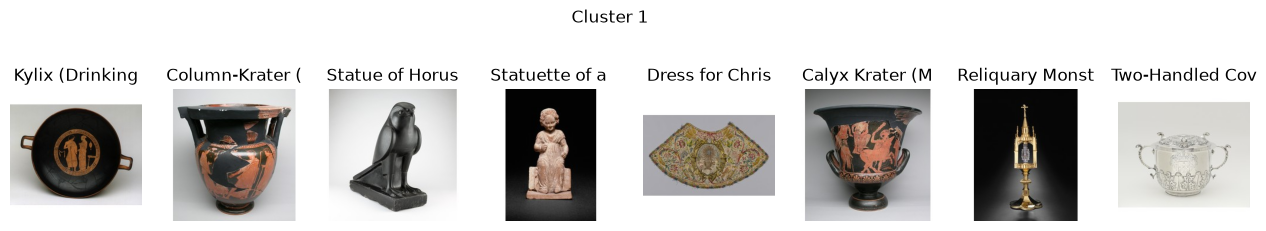

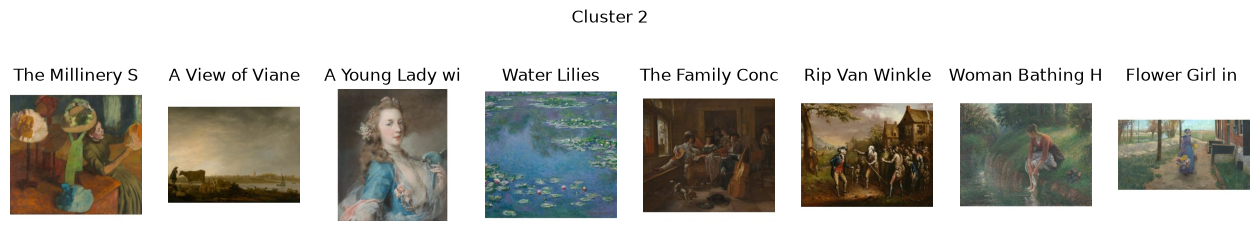

In [26]:
modelo_final = KMeans(
    n_clusters=3,
    n_init=10,
    random_state=0
)

metadata["cluster"] = modelo_final.fit_predict(X_features_pca)

for cluster in sorted(metadata["cluster"].unique()):
    mostrar_cluster(cluster)

Los grupos obtenidos mediante Features PCA presentan una interpretación visual más clara que los obtenidos mediante pixeles. El cluster 0 concentra principalmente obras gráficas y bidimensionales, el cluster 1 contiene mayoritariamente objetos tridimensionales y artes decorativas, mientras que el cluster 2 está compuesto principalmente por pinturas y escenas "pictóricas" 

Si bien esta representación obtiene un silhouette menor que pixeles PCA, los grupos obtenidos resultan más coherentes con el objetivo de identificar obras visualmente similares. Por esta razón, se selecciona K-means con k=3 sobre Features PCA como solución final.

### Misión 3

In [27]:
def vecinos(X, i, k=5):
    dist = pairwise_distances(X)
    return np.argsort(dist[i])[1:k+1]

Elegimos 3 obras

In [28]:
indices = [metadata[metadata["cluster"] == c].index[0] for c in sorted(metadata["cluster"].unique())]

for i in indices:
    print("\n", metadata.iloc[i]["title"],
          "- Cluster", metadata.iloc[i]["cluster"])

    for nombre, X in representaciones.items():
        idx = vecinos(X, i)

        print("\n", nombre)
        display(
            metadata.iloc[idx][
                ["title", "classification_title", "cluster"]
            ]
        )


 The Last Drop - Cluster 0

 Pixeles


,title,classification_title,cluster
239,Geese in a Farmyard,crayon,0
45,"The cannon 'Mons Meg' at Edinburgh Castle, and...",salted paper print,0
11,Two-Handled Covered Cup,drinking vessel,1
235,"The First Ten Minutes, plate two from The Leic...",aquatint,0
145,Les Propos de Thomas Vireloque: Misere et cord...,lithograph,0



 Features


,title,classification_title,cluster
207,The Little Errand Girl,lithograph,0
235,"The First Ten Minutes, plate two from The Leic...",aquatint,0
239,Geese in a Farmyard,crayon,0
42,"Winter, from The Seasons",weaving - tapestry,0
275,The Triumph of Bacchus,print,0



 pixeles PCA


...

,title,classification_title,cluster
256,Lady Sarah Bunbury Sacrificing to the Graces,oil on canvas,2
199,The Two Disciples at the Tomb,oil on canvas,2
255,The Drinkers,oil on canvas,2
253,Portrait Bust of a Woman,sculpture,1
278,Woman Reading,oil on canvas,2



 pixeles PCA


,title,classification_title,cluster
228,The Emperor Sailing from The Story of the Empe...,weaving - tapestry,0
18,The Family Concert,oil on canvas,2
248,Pardon in Brittany,oil on canvas,2
185,Painting with Green Center,painting,2
149,Bar-room Scene,painting,2



 Features PCA


,title,classification_title,cluster
256,Lady Sarah Bunbury Sacrificing to the Graces,oil on canvas,2
253,Portrait Bust of a Woman,sculpture,1
199,The Two Disciples at the Tomb,oil on canvas,2
255,The Drinkers,oil on canvas,2
267,Saint Francis Kneeling in Meditation,oil on canvas,2



 The Last Drop - Cluster 0


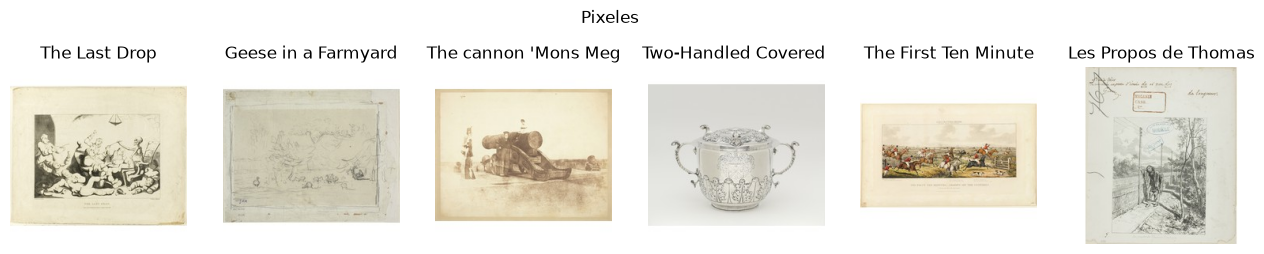

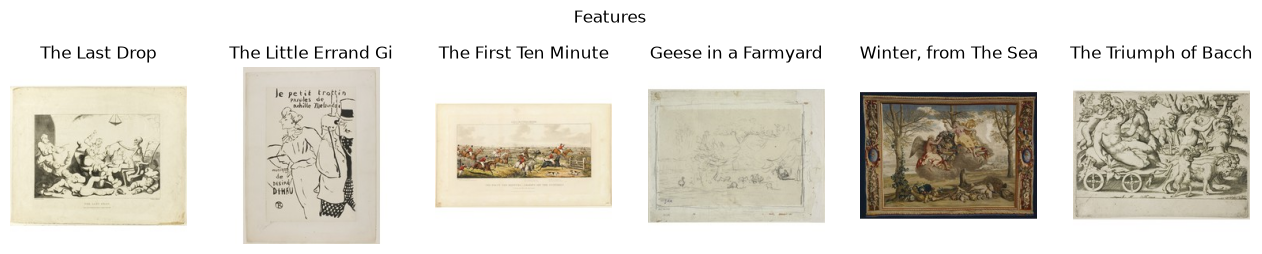

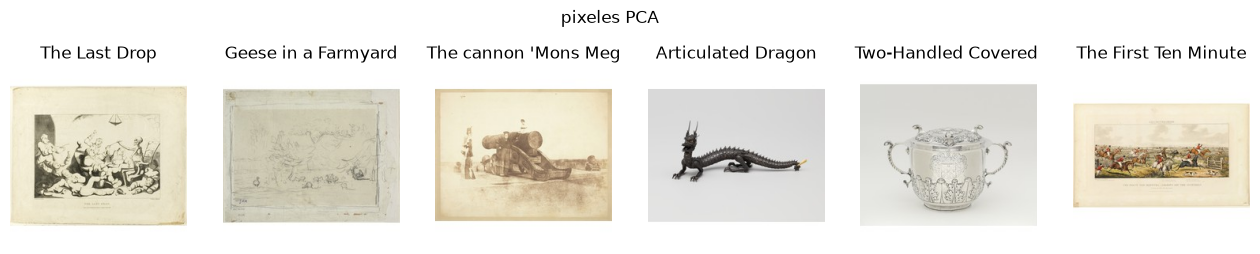

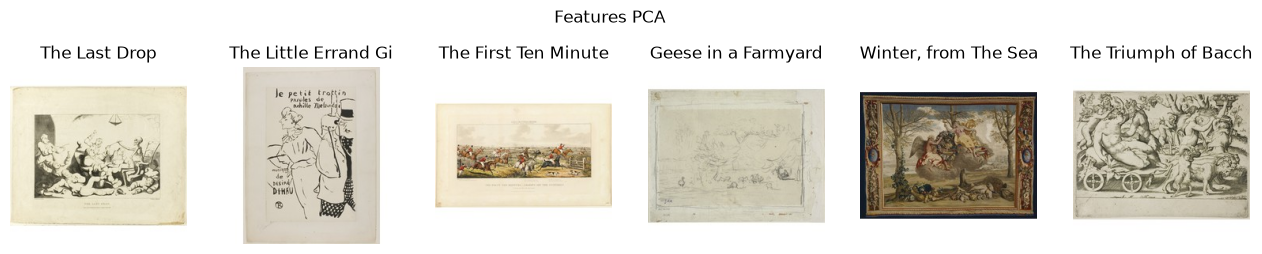


 Kylix (Drinking Cup) - Cluster 1


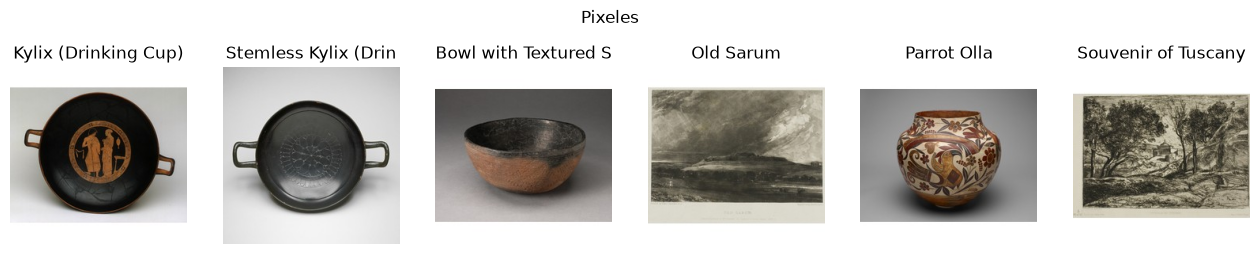

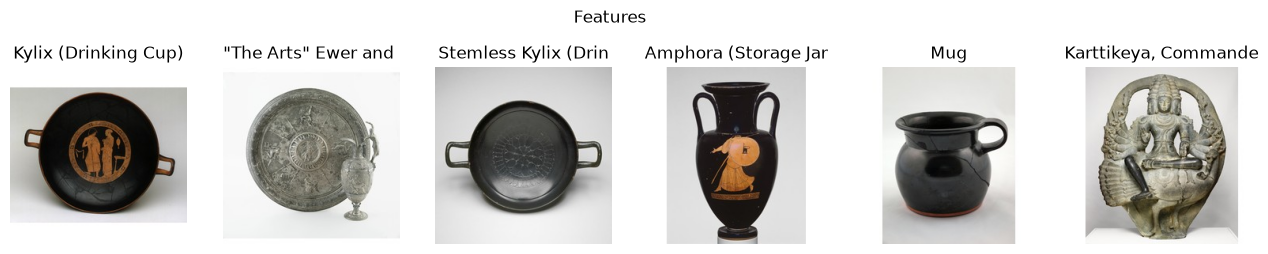

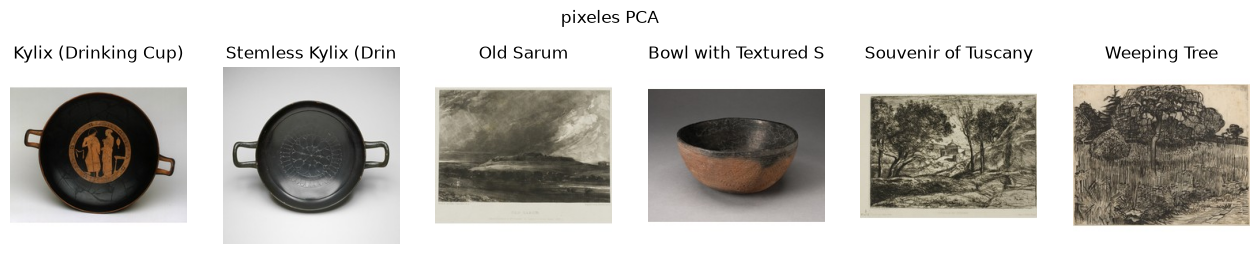

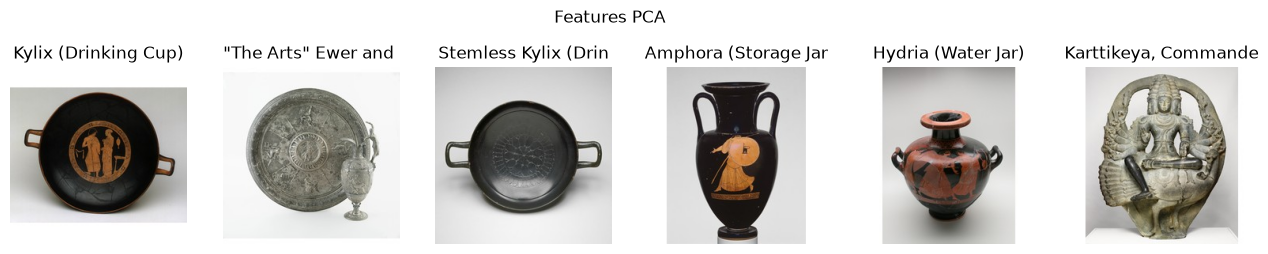


 The Millinery Shop - Cluster 2


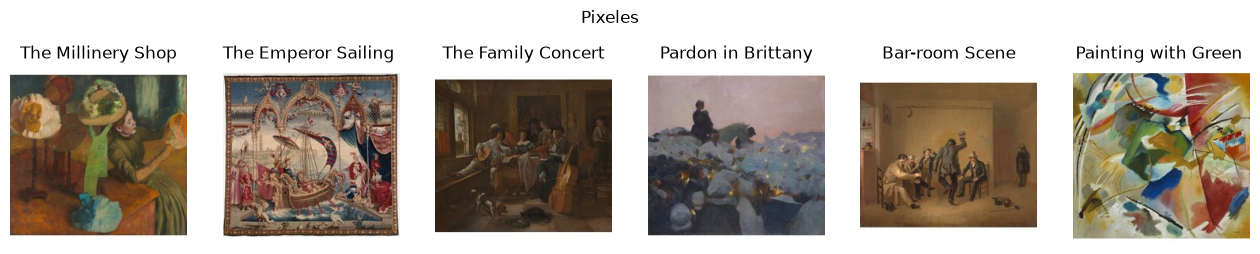

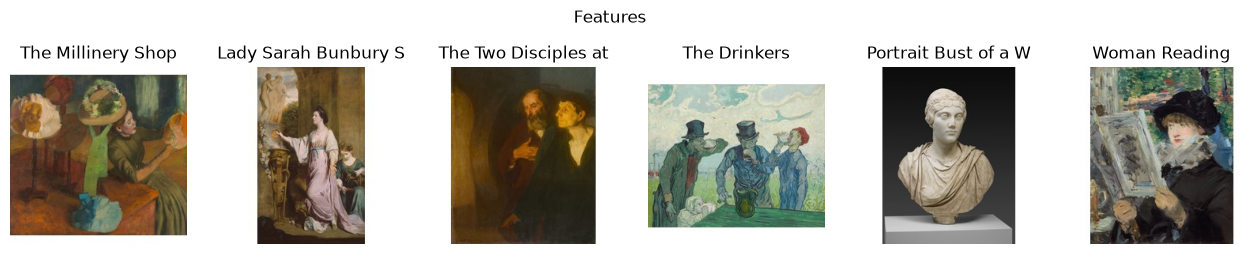

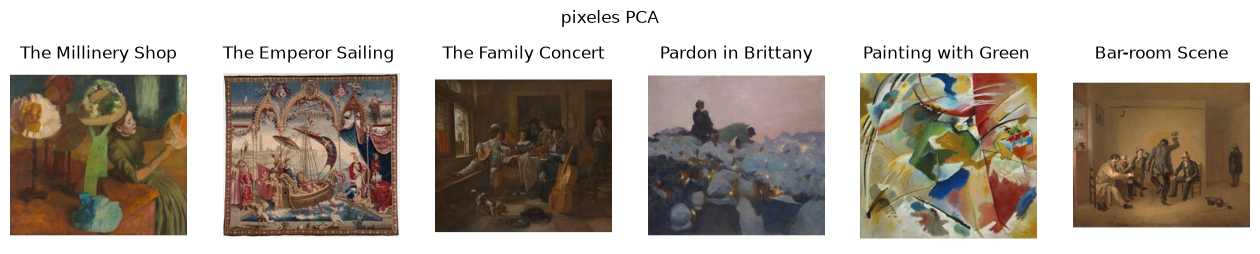

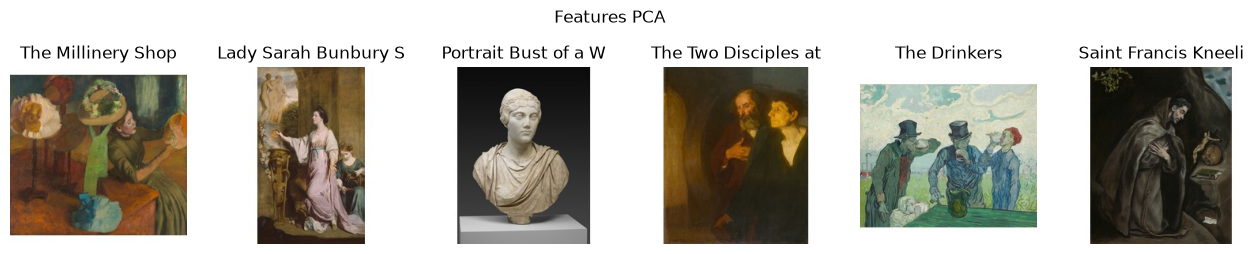

In [29]:
for i in indices:
    print("\n", metadata.iloc[i]["title"],
          "- Cluster", metadata.iloc[i]["cluster"])
    for nombre, X in representaciones.items():
        idx = vecinos(X, i)
        mostrar_vecinos(i, idx, nombre)

In [30]:
for nombre, X in representaciones.items():
    coincidencias = []

    for i in range(len(metadata)):
        idx = vecinos(X, i)

        mismo_cluster = (
            metadata.iloc[idx]["cluster"].values
            == metadata.iloc[i]["cluster"]
        )

        coincidencias.append(mismo_cluster.mean())

    print(nombre, round(np.mean(coincidencias), 3))

Pixeles 0.562
Features 0.853
pixeles PCA 0.57
Features PCA 0.847


Vemos que las representaciones basadas en features presentan una mayor consistencia entre vecinos y clusters que las basadas en pixeles. 

En promedio, cerca del 85% de los cinco vecinos más cercanos obtenidos con features pertenecen al mismo cluster, mientras que en pixeles esta proporción es cercana al 56%.

Además, los resultados de Features y Features PCA son prácticamente iguales (0.853 y 0.847), lo que indica que PCA preserva adecuadamente las relaciones de similitud al reducir la dimensionalidad. 

Por lo tanto, junto con la inspección visual de los vecinos, esto respalda que las distancias en este espacio capturan relaciones visuales más útiles para organizar la colección.

#### Misión 4

Hacemos un mapa de la colección

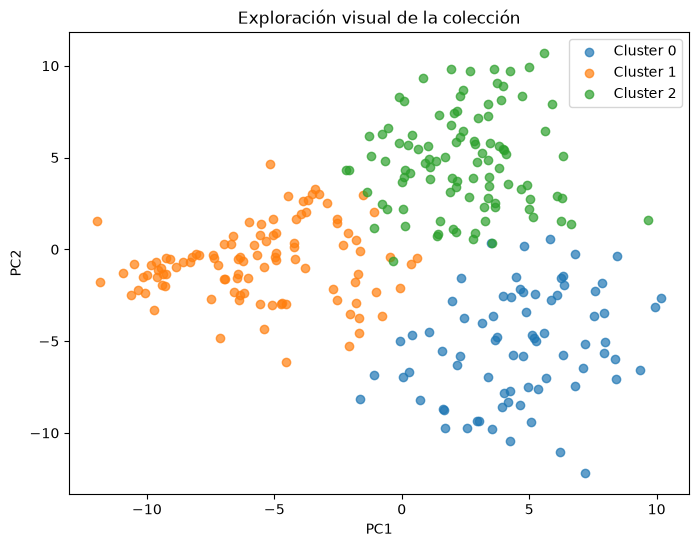

In [31]:
plt.figure(figsize=(8, 6))

for cluster in sorted(metadata["cluster"].unique()):
    mask = metadata["cluster"] == cluster

    plt.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Exploración visual de la colección")
plt.legend()
plt.show()

Un explorador una obra y sus vecinos

In [32]:
dist_features_pca = pairwise_distances(X_features_pca)

def explorar_obra(i):
    vecinos = np.argsort(dist_features_pca[i])[1:6]

    print(
        metadata.iloc[i]["title"],
        "- Cluster",
        metadata.iloc[i]["cluster"]
    )

    mostrar_vecinos(
        i,
        vecinos,
        "Obra y vecinos más cercanos"
    )

The Last Drop - Cluster 0


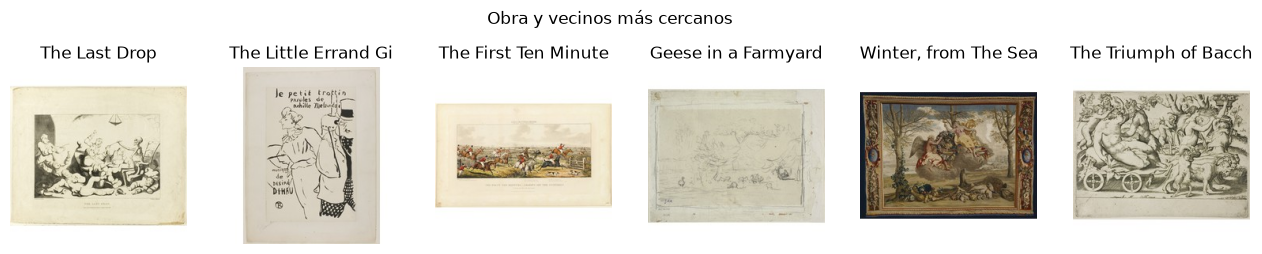

In [33]:
explorar_obra(0)

Amphora (Storage Jar) - Cluster 1


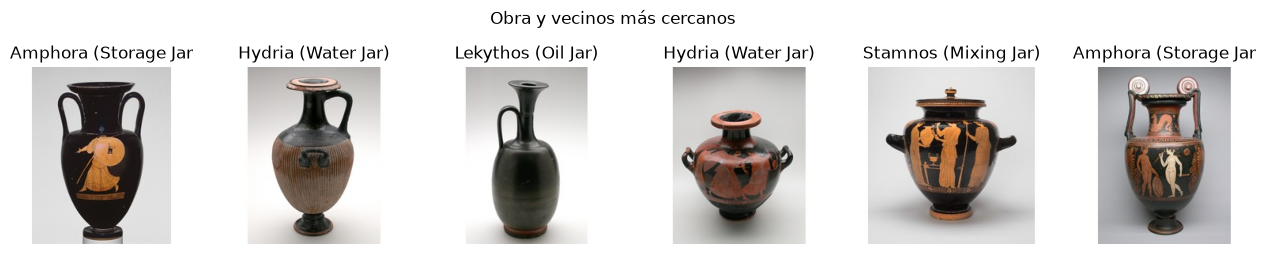

In [34]:
explorar_obra(250)

Casos atípicos, una obra atípica puede ser la que esté más lejos del centro de su propio cluster.

In [35]:
dist_centros = modelo_final.transform(X_features_pca)

atipicos = []

for cluster in sorted(metadata["cluster"].unique()):
    idx = np.where(metadata["cluster"].values == cluster)[0]
    dist = dist_centros[idx, cluster]

    atipicos.append(idx[np.argmax(dist)])

for i in atipicos:
    print(metadata.iloc[i]["title"], "- Cluster", metadata.iloc[i]["cluster"])

The Pheasants from the "Verdures of the Vatican" Series - Cluster 0
Eight Boys - Cluster 1
Are They Thinking about the Grape? (Pensent-ils au raisin?) - Cluster 2


The Pheasants from the "Verdures of the Vatican" Series - Cluster 0


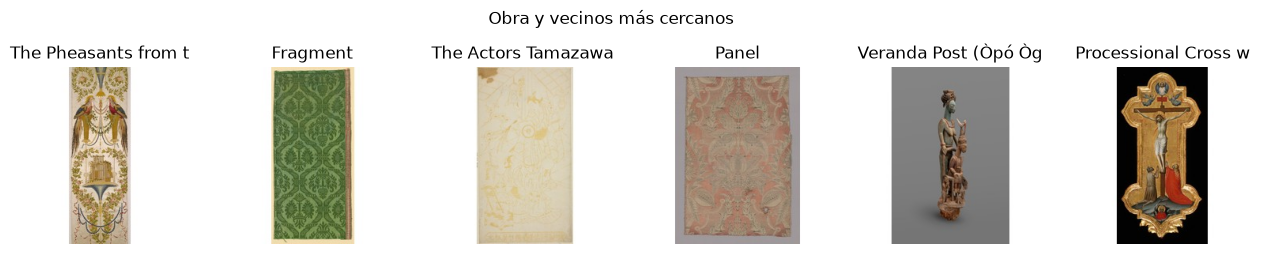

Eight Boys - Cluster 1


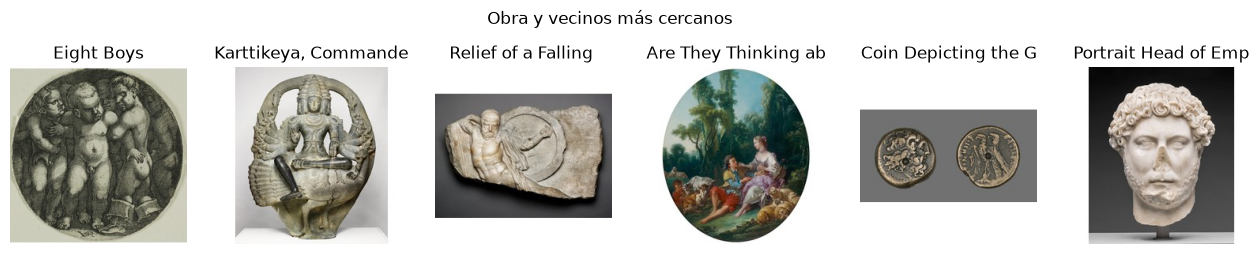

Are They Thinking about the Grape? (Pensent-ils au raisin?) - Cluster 2


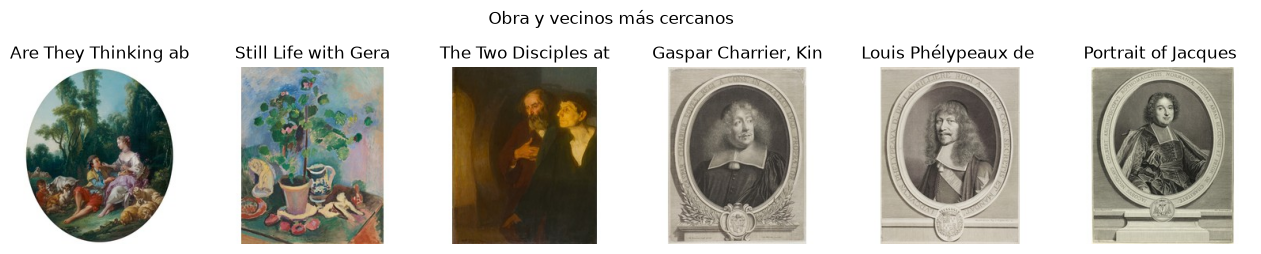

In [36]:
for i in atipicos:
    explorar_obra(i)

Casos de "transición", obras cuyo vecino más cercano pertenezca a otro cluster.

In [37]:
transiciones = []

for i in range(len(metadata)):
    vecino = np.argsort(dist_features_pca[i])[1]

    if metadata.iloc[i]["cluster"] != metadata.iloc[vecino]["cluster"]:
        transiciones.append(i)

transiciones[:5]

[29, 38, 49, 51, 57]

Reliquary Casket of Saints Adrian and Natalia - Cluster 1


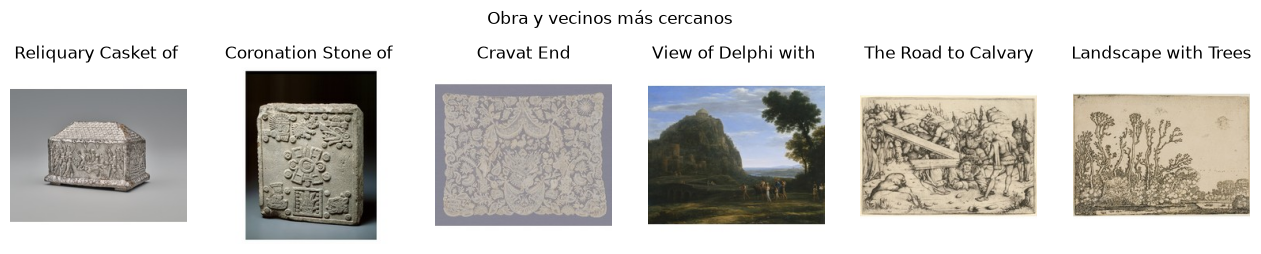

A28: South Carolina Drawing Room, 1775–1800 - Cluster 2


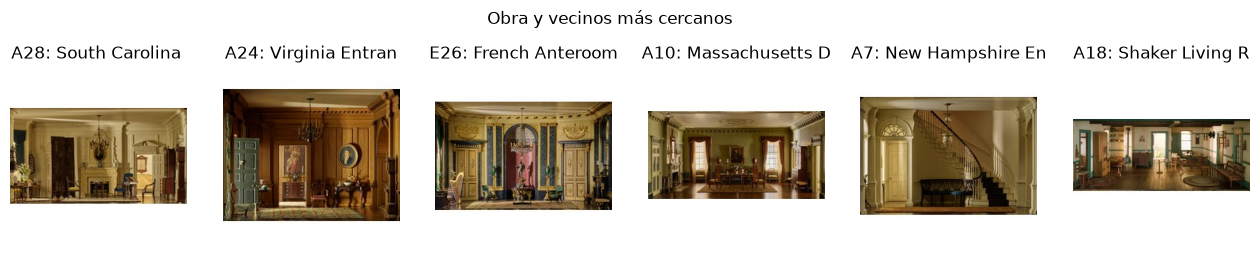

The Cowherd - Cluster 0


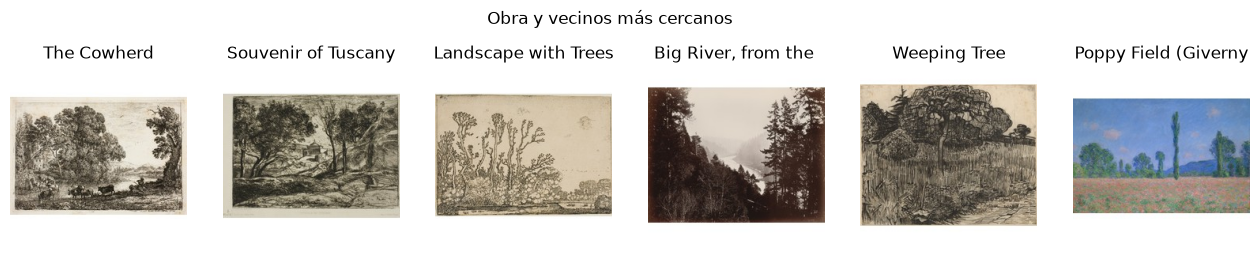

In [38]:
for i in transiciones[:3]:
    explorar_obra(i)

La herramienta permite explorar la colección seleccionando una obra y visualizando sus vecinos más cercanos. 

A partir de ella se observan patrones asociados a obras gráficas, objetos tridimensionales y escenas "pictóricas", además de casos atípicos alejados del centro de sus clusters y obras de transición cuyos vecinos más cercanos pertenecen a otros grupos.

Como cierre, vemos que las features visuales resultaron ser la representación más útil para organizar y explorar la colección. Aunque los pixeles produjeron clusters con mayor silhouette, estos estaban fuertemente influenciados por características globales como fondo y luminosidad. 

Las features, en cambio, generaron vecinos más coherentes y grupos visualmente más interpretables. PCA permitió además reducir esta representación manteniendo prácticamente las mismas relaciones de similitud.